In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2",
                                        output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6523.50it/s]


Ready!


In [2]:
text = "The cat sat on the"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

hidden_states = outputs.hidden_states  # 13 layers

ln_f    = model.transformer.ln_f
lm_head = model.lm_head

print(f"Text: {text}")
print(f"\nLogit Lens — Top prediction per layer:")
print(f"\n{'Layer':<10} {'Top Word':<20} {'Probability'}")
print("-"*45)

for layer_idx in range(13):
    
    hidden = hidden_states[layer_idx][0, -1, :]  # Last token
    
   
    normed = ln_f(hidden)
    
    
    logits = lm_head(normed)
    probs  = torch.softmax(logits, dim=0)
    
    top_id   = probs.argmax().item()
    top_word = tokenizer.decode([top_id])
    top_prob = probs.max().item()
    
    label = "Emb" if layer_idx == 0 else f"L{layer_idx}"
    print(f"{label:<10} {top_word:<20} {top_prob:.4f}")

Text: The cat sat on the

Logit Lens — Top prediction per layer:

Layer      Top Word             Probability
---------------------------------------------
Emb         destro              0.6225
L1          same                0.7029
L2          same                0.8867
L3          same                0.9538
L4          same                0.9323
L5          same                0.8791
L6          same                0.7502
L7          same                0.5276
L8          floor               0.2482
L9          ground              0.2329
L10         floor               0.4628
L11         floor               0.3330
L12         the                 0.0139


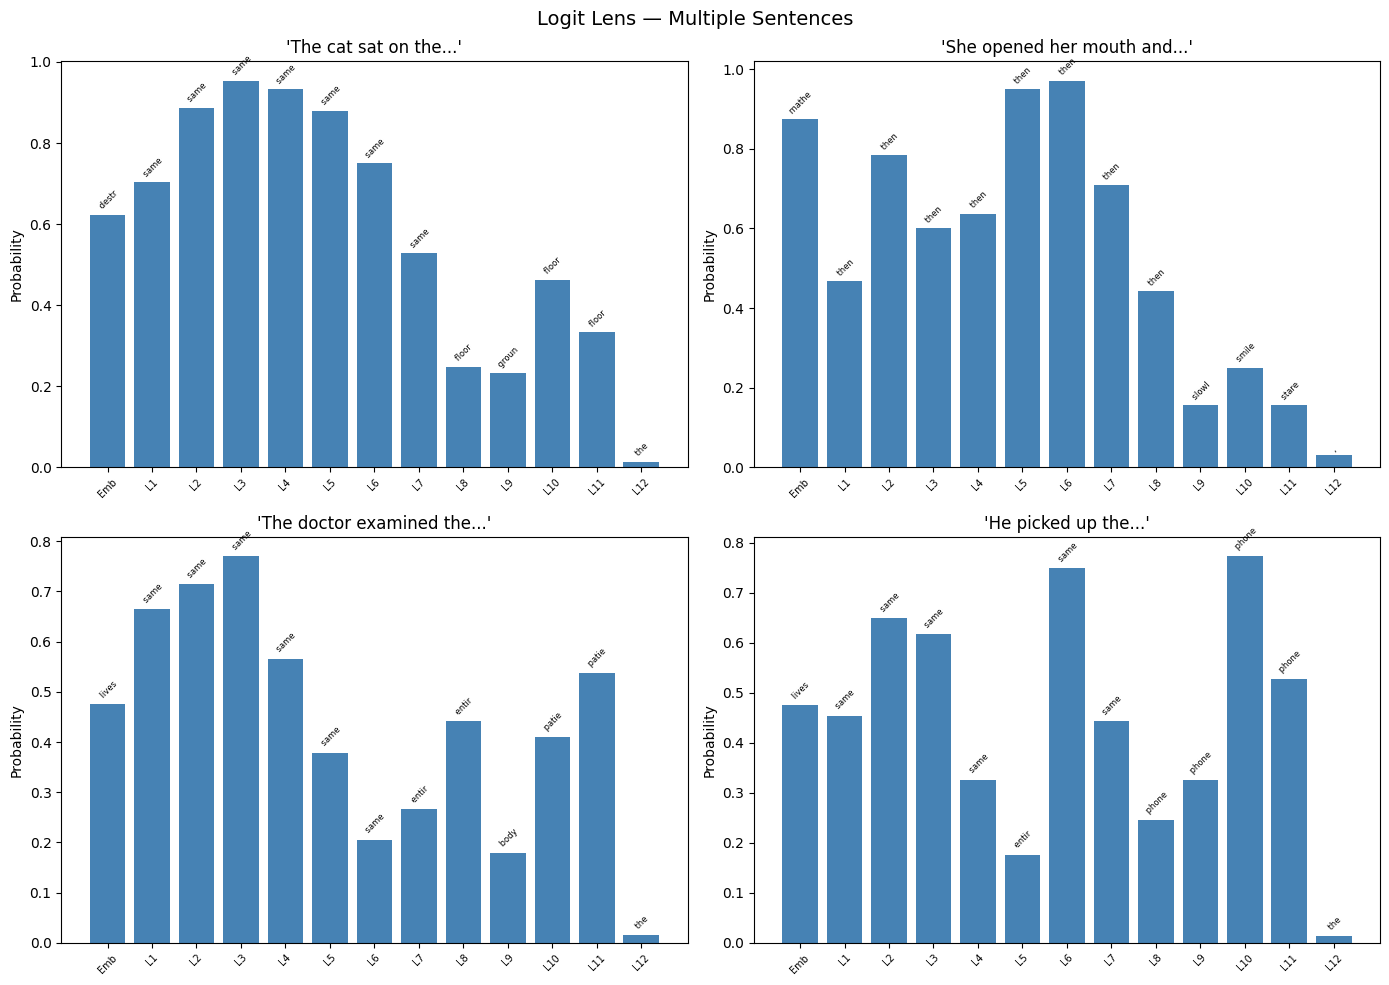

In [3]:
test_sentences = [
    "The cat sat on the",
    "She opened her mouth and",
    "The doctor examined the",
    "He picked up the",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, text in zip(axes.flat, test_sentences):
    inputs = tokenizer(text, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    hidden_states = outputs.hidden_states
    
    top_words = []
    top_probs = []
    
    for layer_idx in range(13):
        hidden = hidden_states[layer_idx][0, -1, :]
        normed = ln_f(hidden)
        logits = lm_head(normed)
        probs  = torch.softmax(logits, dim=0)
        
        top_words.append(tokenizer.decode([probs.argmax().item()]))
        top_probs.append(probs.max().item())
    
    # Plot
    xlabels = ["Emb"] + [f"L{i}" for i in range(1, 13)]
    ax.bar(range(13), top_probs, color="steelblue")
    ax.set_xticks(range(13))
    ax.set_xticklabels(xlabels, rotation=45, fontsize=7)
    ax.set_ylabel("Probability")
    ax.set_title(f"'{text[:30]}...'")
    
    # Word labels
    for i, (word, prob) in enumerate(zip(top_words, top_probs)):
        ax.text(i, prob + 0.01, word[:6], 
                ha='center', fontsize=6, rotation=45)

plt.suptitle("Logit Lens — Multiple Sentences", fontsize=14)
plt.tight_layout()
plt.show()


* Logit Lens shows the intermediate prediction at each layer.
* Early layers (1–7) produce incorrect predictions (e.g., “same”).
* Correct predictions start appearing from Layer 8.
* Deep layers make more confident predictions.
* The LLM gradually “understands” the input layer by layer.
